In [6]:
import pandas as pd

df = pd.read_csv("house_prices.csv")
df


,House_ID,Location,Size_sqft,Bedrooms,Bathrooms,Age_of_House_Years,Price_INR
0,1,Area_5,2330,4,1,17,25286545
1,2,Area_2,959,1,1,25,17612282
2,3,Area_14,4750,3,1,13,25154685
3,4,Area_7,1856,2,1,23,5207002
4,5,Area_8,3530,3,1,22,45373653
...,...,...,...,...,...,...,...
195,196,Area_11,1370,3,2,1,6089880
196,197,Area_19,4808,4,3,30,37132448
197,198,Area_4,2230,1,4,4,29142139
198,199,Area_4,2017,2,2,25,36071676


In [10]:
df.shape
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   House_ID            200 non-null    int64 
 1   Location            200 non-null    object
 2   Size_sqft           200 non-null    int64 
 3   Bedrooms            200 non-null    int64 
 4   Bathrooms           200 non-null    int64 
 5   Age_of_House_Years  200 non-null    int64 
 6   Price_INR           200 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 11.1+ KB


,House_ID,Location,Size_sqft,Bedrooms,Bathrooms,Age_of_House_Years,Price_INR
0,1,Area_5,2330,4,1,17,25286545
1,2,Area_2,959,1,1,25,17612282
2,3,Area_14,4750,3,1,13,25154685
3,4,Area_7,1856,2,1,23,5207002
4,5,Area_8,3530,3,1,22,45373653


In [12]:
df.describe()


,House_ID,Size_sqft,Bedrooms,Bathrooms,Age_of_House_Years,Price_INR
count,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,100.500000,2728.360000,3.550000,2.505000,14.935000,2.793519e+07
std,57.879185,1404.517654,1.703529,1.125303,9.021514,1.369789e+07
min,1.000000,413.000000,1.000000,1.000000,0.000000,6.135830e+05
25%,50.750000,1523.750000,2.000000,1.750000,7.000000,1.756522e+07
50%,100.500000,2597.500000,3.000000,2.500000,15.000000,2.878981e+07
75%,150.250000,4010.750000,5.000000,4.000000,23.000000,3.910420e+07
max,200.000000,4982.000000,6.000000,4.000000,30.000000,4.978915e+07


In [14]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct


,0
House_ID,0.0
Location,0.0
Size_sqft,0.0
Bedrooms,0.0
Bathrooms,0.0
Age_of_House_Years,0.0
Price_INR,0.0


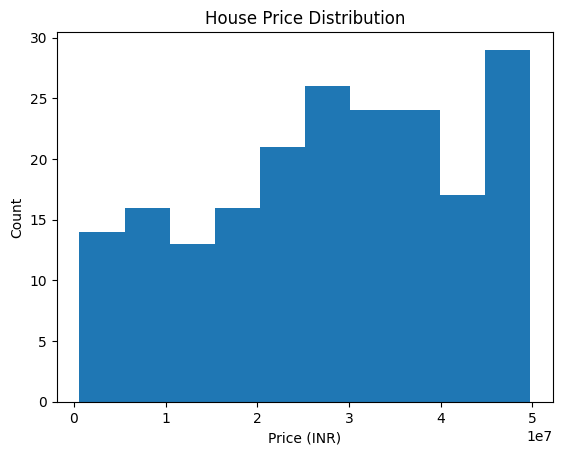

In [17]:
import matplotlib.pyplot as plt
plt.hist(df['Price_INR'], bins=10)
plt.title("House Price Distribution")
plt.xlabel("Price (INR)")
plt.ylabel("Count")
plt.show()


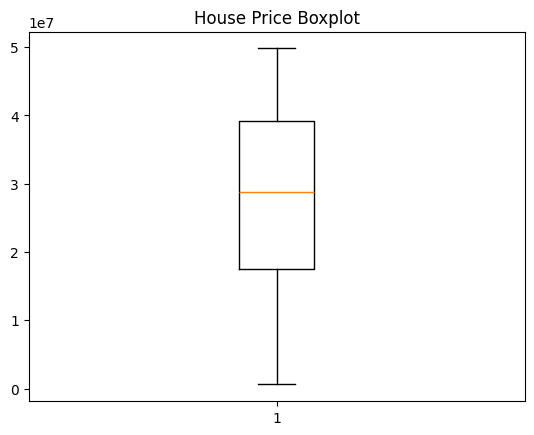

In [19]:
plt.boxplot(df['Price_INR'])
plt.title("House Price Boxplot")
plt.show()


In [21]:
Q1 = df['Price_INR'].quantile(0.25)
Q3 = df['Price_INR'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound


(np.float64(-14743241.25), np.float64(71412658.75))

In [23]:
df['price_outlier'] = (
    (df['Price_INR'] < lower_bound) |
    (df['Price_INR'] > upper_bound)
)

df['price_outlier'].value_counts()


,count
price_outlier,
False,200


In [26]:
df_cleaned = df[~df['price_outlier']]
#Extreme prices can distort averages and correlations, so outliers were removed to improve analysis stability

In [29]:
df['Price_INR'] = df['Price_INR'].clip(lower_bound, upper_bound)
df_cleaned = df.copy()
#Capping preserves data size while reducing the impact of extreme values.

In [31]:
corr = df_cleaned[
    ['Size_sqft', 'Bedrooms', 'Bathrooms', 'Age_of_House_Years', 'Price_INR']
].corr()

corr
#Size_sqft has strong positive correlation with Price

#More bedrooms → higher price

#Older houses tend to have lower prices

,Size_sqft,Bedrooms,Bathrooms,Age_of_House_Years,Price_INR
Size_sqft,1.000000,-0.051711,-0.012671,0.029522,0.117302
Bedrooms,-0.051711,1.000000,0.053607,-0.097063,-0.065320
Bathrooms,-0.012671,0.053607,1.000000,-0.070504,0.091339
Age_of_House_Years,0.029522,-0.097063,-0.070504,1.000000,-0.044197
Price_INR,0.117302,-0.065320,0.091339,-0.044197,1.000000


In [32]:
df_cleaned.to_csv("cleaned_dataset.csv", index=False)
